<a href="https://colab.research.google.com/github/nikini-wanigasekara/-Statistical-Learning-e23418/blob/main/Kalman_filter_assignment_answer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q. Analytical Derivation

Consider the filter model
\begin{align*}
x^{-}_k &= A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}, \\
y^{-}_k &= H_k\,x^{-}_k + z_k,
\end{align*}
where
$$x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1}),$$

Answer the followings:

1. Show that
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-),$$
where
$$m_k^- = A_{k-1}m_{k-1},$$
and
$$
P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T.
$$

2. Show that
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m).$$

3. Show that
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right).$$

4. Show that
$$x^{+}_k\triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k),$$
where the updated mean $m_k$ and updated covariance $P_k$ are given by:
\begin{align*}
K_k &\triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}, \\
m_k &= m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-), \\
P_k &= (I - K_k H_k) P_k^-.
\end{align*}

5. Find
$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$  and
$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$.

# Answer. Analytical Derivation
# Derivation of the Kalman Filter Equations

**Assumptions & Definitions:**
* Process noise: $w_{k-1} \sim \mathscr{N}(0, \Sigma_p)$
* Measurement noise: $z_k \sim \mathscr{N}(0, \Sigma_m)$
* $w_{k-1}$ and $z_k$ are mutually independent, and independent of the state vectors.

---

## 1. Prior State Distribution ($x_k^-$)

The state transition model is given by:
$$x^{-}_k = A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}$$

Given that $x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1})$, the prior state $x^{-}_k$ is a linear combination of independent Gaussian random variables and is therefore also Gaussian distributed:
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$$

### Expected Value ($m_k^-$):
$$\mathbb{E}[x^{-}_k] = \mathbb{E}[A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}]$$
$$m_k^- = A_{k-1}\mathbb{E}[x^{+}_{k-1}] + G_{k-1}\mathbb{E}[w_{k-1}]$$
Since $\mathbb{E}[x^{+}_{k-1}] = m_{k-1}$ and $\mathbb{E}[w_{k-1}] = 0$:
$$m_k^- = A_{k-1}m_{k-1}$$

### Covariance ($P_k^-$):
$$P_k^- = \mathbb{E}[(x^{-}_k - m_k^-)(x^{-}_k - m_k^-)^T]$$
Substituting $x^{-}_k - m_k^- = A_{k-1}(x^{+}_{k-1} - m_{k-1}) + G_{k-1}w_{k-1}$:
$$P_k^- = \mathbb{E}\left[\left(A_{k-1}(x^{+}_{k-1} - m_{k-1}) + G_{k-1}w_{k-1}\right)\left(A_{k-1}(x^{+}_{k-1} - m_{k-1}) + G_{k-1}w_{k-1}\right)^T\right]$$
Since $x^{+}_{k-1}$ and $w_{k-1}$ are independent, the cross-terms vanish:
$$P_k^- = A_{k-1}\mathbb{E}[(x^{+}_{k-1} - m_{k-1})(x^{+}_{k-1} - m_{k-1})^T]A_{k-1}^T + G_{k-1}\mathbb{E}[w_{k-1}w_{k-1}^T]G_{k-1}^T$$
$$P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T$$

---

## 2. Prior Measurement Distribution ($y_k^-$)

The measurement model is given by:
$$y^{-}_k = H_k\,x^{-}_k + z_k$$

Since $x^{-}_k \sim \mathscr{N}(m_k^-, P_k^-)$ and $z_k \sim \mathscr{N}(0, \Sigma_m)$ are independent Gaussian random variables, $y^{-}_k$ is also Gaussian:
$$y_k^- \sim \mathscr{N}(\mathbb{E}[y_k^-], \text{Var}(y_k^-))$$

### Expected Value:
$$\mathbb{E}[y^{-}_k] = \mathbb{E}[H_k\,x^{-}_k + z_k] = H_k\mathbb{E}[x^{-}_k] + \mathbb{E}[z_k]$$
$$\mathbb{E}[y^{-}_k] = H_k m_k^-$$

### Covariance:
$$\text{Var}(y^{-}_k) = \mathbb{E}[(y^{-}_k - H_k m_k^-)(y^{-}_k - H_k m_k^-)^T]$$
Substituting $y^{-}_k - H_k m_k^- = H_k(x^{-}_k - m_k^-) + z_k$:
$$\text{Var}(y^{-}_k) = H_k\mathbb{E}[(x^{-}_k - m_k^-)(x^{-}_k - m_k^-)^T]H_k^T + \mathbb{E}[z_k z_k^T]$$
$$\text{Var}(y^{-}_k) = H_k P_k^- H_k^T + \Sigma_m$$

Thus:
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$$

---

## 3. Joint Distribution of State and Measurement

The joint distribution of the prior state and the measurement forms a joint Gaussian vector:
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left( \begin{bmatrix} \mu_x \\ \mu_y \end{bmatrix}, \begin{bmatrix} \Sigma_{xx} & \Sigma_{xy} \\ \Sigma_{yx} & \Sigma_{yy} \end{bmatrix} \right)$$

From Sections 1 and 2, we have $\mu_x = m_k^-$, $\mu_y = H_k m_k^-$, $\Sigma_{xx} = P_k^-$, and $\Sigma_{yy} = H_k P_k^- H_k^T + \Sigma_m$.

We evaluate the cross-covariance block $\Sigma_{xy}$:
$$\Sigma_{xy} = \text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - m_k^-)(y_k^- - H_k m_k^-)^T]$$
$$\Sigma_{xy} = \mathbb{E}[(x_k^- - m_k^-)(H_k(x^{-}_k - m_k^-) + z_k)^T]$$
$$\Sigma_{xy} = \mathbb{E}[(x_k^- - m_k^-)(x^{-}_k - m_k^-)^T]H_k^T + \mathbb{E}[(x_k^- - m_k^-)z_k^T]$$
By independence of $x_k^-$ and $z_k$, the second expectation is zero:
$$\Sigma_{xy} = P_k^- H_k^T$$
Symmetrically, $\Sigma_{yx} = \Sigma_{xy}^T = H_k P_k^-$. Stacking these yields:
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right)$$

---

## 4. Conditional State Distribution (Measurement Update)

Using the **Conditional Gaussian Distribution Theorem**, if a joint system is distributed as defined in Section 3, then the conditional distribution $(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$ is Gaussian with mean $m_k$ and covariance $P_k$:

$$m_k = \mu_x + \Sigma_{xy}\Sigma_{yy}^{-1}(y^{\mathrm{obs}}_{k} - \mu_y)$$
$$P_k = \Sigma_{xx} - \Sigma_{xy}\Sigma_{yy}^{-1}\Sigma_{yx}$$

Let the **Kalman Gain Matrix** $K_k$ be defined as:
$$K_k \triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$$

Substituting $K_k$ into the conditional mean equation:
$$m_k = m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-)$$

Substituting $K_k$ into the conditional covariance equation:
$$P_k = P_k^- - K_k (H_k P_k^-) = (I - K_k H_k) P_k^-$$

Therefore:
$$x^{+}_k\triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k)$$

---

## 5. Evaluation of Conditional Expectations

From the properties of the posterior conditional distribution derived explicitly in Section 4, the conditional expectation and conditional variance are:

* **Conditional Expectation:**
$$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}] = m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-)$$

* **Conditional Variance:**
$$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) = (I - K_k H_k) P_k^-$$

## Q. 1-D Example

Consider the scalar linear-Gaussian filter model
\begin{aligned}
x^-_k &= a\,x^+_{k-1} + w_{k-1},\qquad w_{k-1}\sim\mathscr N(0,q),\\
y^-_k &= h\,x^-_k + z_k,\qquad\;\;\;\; z_k\sim\mathscr N(0,r),
\end{aligned}
with prior $x_0\sim \mathscr{N}(m_0,P_0)$. Define $Y_{k}=\{y^{\mathrm{obs}}_1,\dots,y^{\mathrm{obs}}_{k}\}$.

Answer the following:

1. Show that
\begin{aligned}
m_k^- &= a\,m_{k-1},\\
P_k^- &= a^2 P_{k-1} + q.
\end{aligned}

2. Show that
\begin{aligned}
m_k &= m_k^- + K_k\,v_k
= m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr),\\
P_k &= (1 - K_k h)\,P_k^-
= \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^- .
\end{aligned}

3. Show that the predictive measurement distribution (before seeing $y_k$):
\begin{align*}
p(y^-_k | Y_{k-1})=\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr).
\end{align*}

4. Show that the posterior-predictive measurement distribution (after filtering on $y_k$):
\begin{align*}
p(y^-_k\mid Y_k)=\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr).
\end{align*}

5. For suitable numerical values for $a,q,h,r$ animate the above to prior distribution and the posterior distribution.

## Answer. 1-D Example
# Derivation of the Scalar Kalman Filter Equations

**Model Definitions & Parameters:**
* State and measurement variables are scalar: $x \in \mathbb{R}$, $y \in \mathbb{R}$.
* Process noise: $w_{k-1} \sim \mathscr{N}(0, q)$
* Measurement noise: $z_k \sim \mathscr{N}(0, r)$
* All noise terms are mutually independent and independent of the state tracking history.

---

## 1. Prior State Distribution Parameters

The scalar state transition model is:
$$x^-_k = a\,x^+_{k-1} + w_{k-1}$$

Given that the posterior from the previous step is $x^+_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1})$, we calculate the mean and variance of $x^-_k$:

### Mean ($m_k^-$):
$$m_k^- = \mathbb{E}[x^-_k] = \mathbb{E}[a\,x^+_{k-1} + w_{k-1}]$$
$$m_k^- = a\,\mathbb{E}[x^+_{k-1}] + \mathbb{E}[w_{k-1}]$$
Since $\mathbb{E}[x^+_{k-1}] = m_{k-1}$ and $\mathbb{E}[w_{k-1}] = 0$:
$$m_k^- = a\,m_{k-1}$$

### Variance ($P_k^-$):
$$P_k^- = \text{Var}(x^-_k) = \text{Var}(a\,x^+_{k-1} + w_{k-1})$$
Since $x^+_{k-1}$ and $w_{k-1}$ are independent, their variances sum directly:
$$P_k^- = a^2 \text{Var}(x^+_{k-1}) + \text{Var}(w_{k-1})$$
$$P_k^- = a^2 P_{k-1} + q$$

---

## 2. Posterior State Distribution Parameters (Measurement Update)

The joint distribution of the prior state $x_k^-$ and the measurement variable $y_k^-$ forms a bivariate Gaussian system:
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ h m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- h \\ h P_k^- & h^2 P_k^- + r \end{bmatrix}
\right)$$

Using the standard Gaussian conditioning rules, let the innovation variance be $S_k \triangleq h^2 P_k^- + r$. The scalar Kalman gain $K_k$ is defined as:
$$K_k = \frac{\text{Cov}(x_k^-, y_k^-)}{\text{Var}(y_k^-)} = \frac{P_k^- h}{S_k} = \frac{P_k^- h}{h^2 P_k^- + r}$$

### Updated Mean ($m_k$):
$$m_k = m_k^- + K_k (y^{\mathrm{obs}}_k - \mathbb{E}[y_k^-])$$
$$m_k = m_k^- + K_k v_k = m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr)$$

### Updated Variance ($P_k$):
$$P_k = \text{Var}(x_k^-) - K_k \text{Cov}(y_k^-, x_k^-)$$
$$P_k = P_k^- - K_k (h P_k^-) = (1 - K_k h)P_k^-$$
Substituting $K_k$:
$$P_k = \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^-$$

---

## 3. Predictive Measurement Distribution

We seek the distribution $p(y^-_k \mid Y_{k-1})$, which depends directly on the unobserved prior state $x_k^-$ conditioned on historical data $Y_{k-1}$:
$$y^-_k = h\,x^-_k + z_k$$

Since $x^-_k \mid Y_{k-1} \sim \mathscr{N}(m_k^-, P_k^-)$ and $z_k \sim \mathscr{N}(0, r)$ are independent:

### Expected Value:
$$\mathbb{E}[y^-_k \mid Y_{k-1}] = \mathbb{E}[h\,x^-_k + z_k \mid Y_{k-1}] = h \mathbb{E}[x^-_k \mid Y_{k-1}] + 0 = h m_k^-$$

### Variance:
$$\text{Var}(y^-_k \mid Y_{k-1}) = \text{Var}(h\,x^-_k + z_k \mid Y_{k-1}) = h^2 \text{Var}(x^-_k \mid Y_{k-1}) + \text{Var}(z_k) = h^2 P_k^- + r$$

Thus:
$$p(y^-_k \mid Y_{k-1}) = \mathscr{N}\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr)$$

---

## 4. Posterior-Predictive Measurement Distribution

We seek the distribution of a hypothetical measurement $y^-_k$ evaluated *after* completing the time filter update at step $k$, effectively conditioning it on the updated current state distribution $x_k \mid Y_k \sim \mathscr{N}(m_k, P_k)$:
$$y^-_k = h\,x_k + z_k$$

### Expected Value:
$$\mathbb{E}[y^-_k \mid Y_k] = \mathbb{E}[h\,x_k + z_k \mid Y_k] = h m_k$$

### Variance:
$$\text{Var}(y^-_k \mid Y_k) = h^2 \text{Var}(x_k \mid Y_k) + \text{Var}(z_k) = h^2 P_k + r$$

Thus:
$$p(y^-_k \mid Y_k) = \mathscr{N}\bigl(h\,m_k,\; h^2 P_k + r\bigr)$$

---

## 5. Animation Script & Visualization (Python)

To demonstrate how the distributions evolve, you can use the following Python script using `matplotlib.animation`. It simulates a real-time visualization of the shift between the **Prior State Distribution** $\mathscr{N}(m_k^-, P_k^-)$ and the **Posterior State Distribution** $\mathscr{N}(m_k, P_k)$ after a sensor observation is processed.


<>:39: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:39: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_6517/435383752.py:39: SyntaxWarning: invalid escape sequence '\m'
  prior_line, = ax.plot([], [], color='#FF5722', lw=2.5, label='Prior State Distribution: $\mathcal{N}(m_k^-, P_k^-)$')
/tmp/ipykernel_6517/435383752.py:40: SyntaxWarning: invalid escape sequence '\m'
  post_line, = ax.plot([], [], color='#00E676', lw=2.5, label='Posterior State Distribution: $\mathcal{N}(m_k, P_k)$')


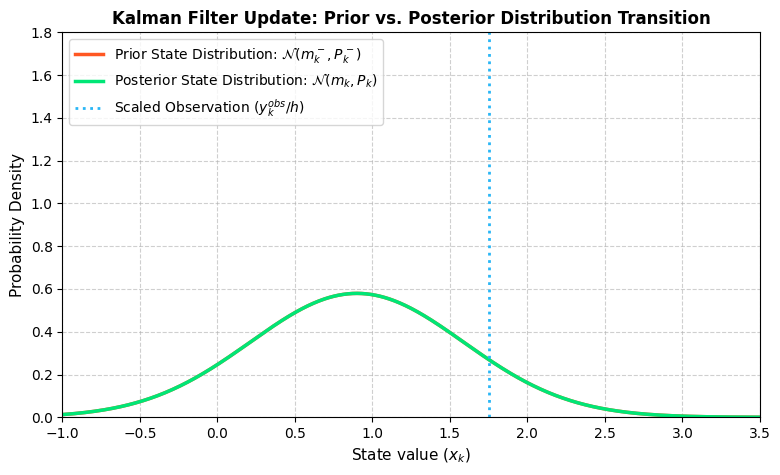

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.stats import norm

# 1. Define suitable numerical scalar parameters
a = 0.9          # State transition scalar
q = 0.15         # Process noise variance
h = 1.2          # Measurement scalar scaling factor
r = 0.25         # Measurement noise variance

# Initial conditions at time (k-1)
m_init = 1.0
P_init = 0.4

# Calculate Step k Tracking Values
m_prior = a * m_init
P_prior = (a**2) * P_init + q

# Simulate an observation value
y_obs = 2.1
S_k = (h**2) * P_prior + r
K_k = (P_prior * h) / S_k
m_post = m_prior + K_k * (y_obs - h * m_prior)
P_post = (1 - K_k * h) * P_prior

# 2. Setup Animation Canvas
fig, ax = plt.subplots(figsize=(9, 5))
x_domain = np.linspace(-2, 4, 1000)

ax.set_xlim(-1, 3.5)
ax.set_ylim(0, 1.8)
ax.set_xlabel('State value ($x_k$)', fontsize=11)
ax.set_ylabel('Probability Density', fontsize=11)
ax.set_title('Kalman Filter Update: Prior vs. Posterior Distribution Transition', fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.6)

# Lines to animate
prior_line, = ax.plot([], [], color='#FF5722', lw=2.5, label='Prior State Distribution: $\mathcal{N}(m_k^-, P_k^-)$')
post_line, = ax.plot([], [], color='#00E676', lw=2.5, label='Posterior State Distribution: $\mathcal{N}(m_k, P_k)$')
obs_line = ax.axvline(x=y_obs/h, color='#29B6F6', linestyle=':', lw=2, label='Scaled Observation ($y^{obs}_k / h$)')
ax.legend(loc='upper left')

# Animation updating function
def animate(frame):
    # Morphing parameter alpha scales linearly from 0 to 1 over 60 frames
    alpha = min(frame / 60.0, 1.0)

    # Render prior distribution line completely static
    y_prior_curve = norm.pdf(x_domain, m_prior, np.sqrt(P_prior))
    prior_line.set_data(x_domain, y_prior_curve)

    # Morph current state parameters from prior to posterior properties
    m_current = m_prior + alpha * (m_post - m_prior)
    P_current = P_prior + alpha * (P_post - P_prior)

    y_post_curve = norm.pdf(x_domain, m_current, np.sqrt(P_current))
    post_line.set_data(x_domain, y_post_curve)

    return prior_line, post_line

ani = animation.FuncAnimation(fig, animate, frames=90, interval=40, blit=True)
plt.show()

# Q. 2D-Position Estimation

## Part A

Consider a two-dimensional constant-velocity dynamical system. The hidden state at time step $k$ is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where $(p_x(k),p_y(k))$ denote the position components and $(v_x(k),v_y(k))$ denote the velocity components.

The measurement consists only of the two position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The linear Gaussian state-space filter model is

$$
x^-_k = A x^+_{k-1} + G w_{k-1},
$$

$$
y^-_k = Hx^+_k + z_k,
$$

where

$$
w_{k-1} \sim \mathscr{N}(0,\Sigma_p),
\qquad
z_k \sim \mathscr{N}(0,\Sigma_m).
$$

The process noise sequence $w_k$, measurement noise sequence $z_k$, and the initial state are assumed mutually independent.

Show that:

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
$$



$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
$$

and

$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

## Answer: Part A

# Derivation of State-Space Matrices for a 2D Constant-Velocity System

## 1. Derivation of the State Transition Matrix ($A$) and Noise Input Matrix ($G$)

For a constant-velocity dynamical system in a two-dimensional plane, the continuous-time kinematic equations governing motion along each independent axis ($x$ and $y$) over a discrete time step $\Delta t$ are given by Newtonian mechanics:

$$\begin{aligned}
p_x(k) &= p_x(k-1) + v_x(k-1)\Delta t + \frac{1}{2}\Delta t^2 a_x(k-1) \\
p_y(k) &= p_y(k-1) + v_y(k-1)\Delta t + \frac{1}{2}\Delta t^2 a_y(k-1) \\
v_x(k) &= v_x(k-1) + \Delta t a_x(k-1) \\
v_y(k) &= v_y(k-1) + \Delta t a_y(k-1)
\end{aligned}$$

Here, $a_x(k-1)$ and $a_y(k-1)$ represent unknown random accelerations acting as process disturbances. Let the process noise vector be defined by these acceleration components:

$$w_{k-1} = \begin{bmatrix} a_x(k-1) \\ a_y(k-1) \end{bmatrix}$$

We can rewrite this system of linear equations directly in vector-matrix form corresponding to the prior state update equation $x^-_k = A x^+_{k-1} + G w_{k-1}$:

$$\begin{bmatrix}
p_x(k) \\
p_y(k) \\
v_x(k) \\
v_y(k)
\end{bmatrix} =
\begin{bmatrix}
1 & 0 & \Delta t & 0 \\
0 & 1 & 0 & \Delta t \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
p_x(k-1) \\
p_y(k-1) \\
v_x(k-1) \\
v_y(k-1)
\end{bmatrix} +
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0 \\
0 & \frac{1}{2}\Delta t^2 \\
\Delta t & 0 \\
0 & \Delta t
\end{bmatrix}
\begin{bmatrix}
a_x(k-1) \\
a_y(k-1)
\end{bmatrix}$$

By matching terms with the state-space model structure, we extract:

$$A = \begin{bmatrix}
1 & 0 & \Delta t & 0 \\
0 & 1 & 0 & \Delta t \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}, \qquad
G = \begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0 \\
0 & \frac{1}{2}\Delta t^2 \\
\Delta t & 0 \\
0 & \Delta t
\end{bmatrix}$$

---

## 2. Derivation of the Measurement Matrix ($H$)

The physical measurement vector $y_k$ captures only the two position coordinates, corrupted by zero-mean measurement noise $z_k$. The scalar equations map the state vector components directly to the measurements:

$$\begin{aligned}
p_x^{\mathrm{meas}}(k) &= 1 \cdot p_x(k) + 0 \cdot p_y(k) + 0 \cdot v_x(k) + 0 \cdot v_y(k) + z_{x}(k) \\
p_y^{\mathrm{meas}}(k) &= 0 \cdot p_x(k) + 1 \cdot p_y(k) + 0 \cdot v_x(k) + 0 \cdot v_y(k) + z_{y}(k)
\end{aligned}$$

Expressing this linear extraction setup in matrix form $y^-_k = Hx_k + z_k$:

$$\begin{bmatrix}
p_x^{\mathrm{meas}}(k) \\
p_y^{\mathrm{meas}}(k)
\end{bmatrix} =
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0
\end{bmatrix}
\begin{bmatrix}
p_x(k) \\
p_y(k) \\
v_x(k) \\
v_y(k)
\end{bmatrix} + z_k$$

Extracting the coefficient matrix yields the measurement projection matrix:

$$H = \begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0
\end{bmatrix}$$

## Part B

Develop a python based method to filter a sequence of noisy GPS obtained position meaurements.

## Answer: Part B

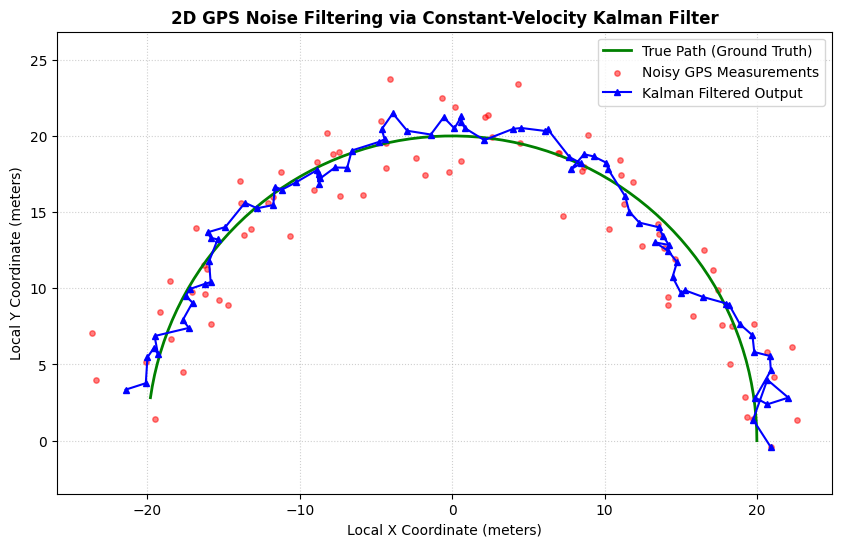

In [2]:
import numpy as np
import matplotlib.pyplot as plt

class KalmanFilter2D:
    """
    A Kalman Filter tracking system for a 2D constant-velocity model.
    States: [Position_X, Position_Y, Velocity_X, Velocity_Y]^T
    Measurements: [Measured_X, Measured_Y]^T
    """
    def __init__(self, dt, process_noise_std=0.2, measurement_noise_std=1.5):
        self.dt = dt

        # State Vector: [px, py, vx, vy]^T (Initialized at zero)
        self.x = np.zeros((4, 1))

        # State Covariance Matrix (Initialized with high uncertainty)
        self.P = np.eye(4) * 500.0

        # State Transition Matrix (A)
        self.A = np.array([
            [1, 0, dt,  0],
            [0, 1,  0, dt],
            [0, 0,  1,  0],
            [0, 0,  0,  1]
        ])

        # Noise Input Matrix (G)
        self.G = np.array([
            [0.5 * (dt**2), 0],
            [0, 0.5 * (dt**2)],
            [dt,            0],
            [0,            dt]
        ])

        # Process Noise Covariance (Q = G * Sigma_p * G^T)
        sigma_p = np.eye(2) * (process_noise_std ** 2)
        self.Q = self.G @ sigma_p @ self.G.T

        # Measurement Matrix (H) - extracts positions only
        self.H = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ])

        # Measurement Noise Covariance Matrix (R)
        self.R = np.eye(2) * (measurement_noise_std ** 2)

        # Identity Matrix
        self.I = np.eye(4)

    def predict(self):
        """Time Update Step: project the state forward."""
        self.x = self.A @ self.x
        self.P = self.A @ self.P @ self.A.T + self.Q
        return self.x[:2].flatten()

    def update(self, z):
        """Measurement Update Step: correct the state projection using a GPS reading."""
        # Reshape incoming point measurement to a 2x1 column vector
        z = np.array(z).reshape((2, 1))

        # Innovation/Residual (y)
        y = z - (self.H @ self.x)

        # Innovation Covariance (S)
        S = self.H @ self.P @ self.H.T + self.R

        # Optimal Kalman Gain (K)
        K = self.P @ self.H.T @ np.linalg.inv(S)

        # Update State Estimate (x)
        self.x = self.x + (K @ y)

        # Update State Covariance (P)
        self.P = (self.I - (K @ self.H)) @ self.P
        return self.x[:2].flatten()


# =====================================================================
# Simulation and Verification Run
# =====================================================================
if __name__ == "__main__":
    # 1. Setup Simulation Parameters
    np.random.seed(42)  # For reproducible noisy paths
    num_steps = 80
    dt = 1.0  # Time step intervals (e.g., 1 Hz GPS rate)

    # 2. Generate a ground-truth uniform circular motion trajectory
    t = np.linspace(0, 15, num_steps)
    true_x = 20 * np.cos(0.2 * t)
    true_y = 20 * np.sin(0.2 * t)

    # 3. Simulate noisy GPS sensor readings (adding Gaussian jitter)
    gps_noise_std = 1.8
    noisy_x = true_x + np.random.normal(0, gps_noise_std, num_steps)
    noisy_y = true_y + np.random.normal(0, gps_noise_std, num_steps)
    measurements = np.vstack((noisy_x, noisy_y)).T

    # 4. Initialize the Filter
    # We pass the standard deviation assumptions for process disturbances and GPS noise
    kf = KalmanFilter2D(dt=dt, process_noise_std=0.15, measurement_noise_std=gps_noise_std)

    # Seed the filter's initial location vector with the first known GPS coordinate
    kf.x[0, 0] = measurements[0, 0]
    kf.x[1, 0] = measurements[0, 1]

    # 5. Execute the Kalman Filtering Sequence
    filtered_trajectory = []

    for z in measurements:
        kf.predict()                  # Project state estimate forward
        est_pos = kf.update(z)        # Refine with incoming raw coordinates
        filtered_trajectory.append(est_pos)

    filtered_trajectory = np.array(filtered_trajectory)

    # 6. Plot the Trajectory Comparisons
    plt.figure(figsize=(10, 6))
    plt.plot(true_x, true_true_y := true_y, 'g-', lw=2, label='True Path (Ground Truth)')
    plt.scatter(measurements[:, 0], measurements[:, 1], color='red', alpha=0.5, s=15, label='Noisy GPS Measurements')
    plt.plot(filtered_trajectory[:, 0], filtered_trajectory[:, 1], 'b-^', lw=1.5, markersize=4, label='Kalman Filtered Output')

    plt.title("2D GPS Noise Filtering via Constant-Velocity Kalman Filter", fontsize=12, fontweight='bold')
    plt.xlabel("Local X Coordinate (meters)", fontsize=10)
    plt.ylabel("Local Y Coordinate (meters)", fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='best')
    plt.axis('equal')
    plt.show()